# 最初に実行するコード

## モジュール

In [1]:
from google.colab import drive
drive.mount('./drive')
drive_root_dir="./drive/My Drive"
import os
!ls
os.chdir(drive_root_dir)

Drive already mounted at ./drive; to attempt to forcibly remount, call drive.mount("./drive", force_remount=True).
drive  sample_data


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import os
import cv2
import random
import time
from PIL import Image
from tqdm import tqdm
import tensorflow as tf
import mainLAB.image_rotate as tfa
from mainLAB.simulated_annealing import SA
from datetime import datetime
import re
import scipy.ndimage as ndimage
from skimage import data, img_as_float
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.metrics import peak_signal_noise_ratio
from skimage.util import random_noise
from skimage.restoration import unwrap_phase
from skimage import io, color, filters
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, Input, Activation, BatchNormalization, Dense, MaxPooling2D, Conv2DTranspose

## 自作関数

In [3]:
def save_gif(dir, flame=1000,loop=0):
    image_folder = dir + "/images"
    output_dir = os.path.join(dir, "animation.gif")
    # 拡張子が .png または .tif の画像を読み込む（昇順でソート）
    image_files = sorted([f for f in os.listdir(image_folder) if f.endswith(('.png', '.tif', '.jpg'))],
                         key=extract_number)

    # フルパスに変換して画像を読み込み
    images = [Image.open(os.path.join(image_folder, f)) for f in image_files]

    # GIFとして保存（ループあり、各フレーム200ms）
    images[0].save(output_dir,
                save_all=True,
                append_images=images[1:],
                duration=flame,   # 各フレーム表示時間（ms）
                loop=loop)

# 数値をキーにして自然順でソート
def extract_number(filename):
    match = re.search(r'\d+', filename)
    return int(match.group()) if match else -1

# 2次元配列を画像で保存する関数
def save_tif(data,title,path):
    data=Image.fromarray(data)
    data.save("./"+ path + "/" + title + ".tif")

# 最終的な推定画像に使う合成開口のローパスフィルター
def lowpass(img):
    return abs(np.fft.ifft2(np.fft.ifftshift( AS_mask * np.fft.fftshift(np.fft.fft2(img)) )))

# ガウシアンノイズを与える関数
def addGaussianNoise(src):
    row,col= src.shape
    mean = 0
    sigma = np.sqrt(src)
    gauss = np.random.normal(mean,sigma,(row,col))
    gauss = gauss.reshape(row,col)
    noisy = src + gauss
    return noisy

# 2Dフーリエ変換
def FT(f):
    return np.fft.fftshift(np.fft.fft2(np.fft.fftshift(f)))

# 2D逆フーリエ変換
def iFT(f):
    return np.fft.fftshift(np.fft.ifft2(np.fft.fftshift(f)))

# 平面波展開（TensorFlow用）
def ASM_tf(input_field, pixel_size, dz, xlambda):
    input_shape = input_field.shape
    # 周波数座標
    dfx = 1.0 / (pixel_size * input_shape[1])
    dfy = 1.0 / (pixel_size * input_shape[0])
    fx = np.arange(-input_shape[1] / 2, input_shape[1] / 2) * dfx
    fy = np.arange(-input_shape[0] / 2, input_shape[0] / 2) * dfy
    fx = tf.constant(fx, dtype=tf.float32)
    fy = tf.constant(fy, dtype=tf.float32)
    fx_mesh, fy_mesh = tf.meshgrid(fx, fy)
    fz2 = 1.0 / xlambda ** 2 - fx_mesh ** 2 - fy_mesh ** 2
    fz2 = tf.where(fz2 > 0.0, fz2, 0.0)
    fz = tf.sqrt(fz2)
    # 伝達関数Hの計算
    H_phase = 2 * np.pi * fz * dz
    H = tf.complex(tf.cos(H_phase), tf.sin(H_phase))

    # 伝搬計算本体
    fft_input = tf.signal.fftshift(tf.signal.fft2d(input_field))
    fft_output = fft_input * H
    output = tf.signal.ifft2d(tf.signal.ifftshift(fft_output))
    return output

# Legendre多項式の基底関数を作成する関数．引数：(最大次数，X_mesh, Y_mesh)
def legendre2D( deg, X, Y ):
    m,n     = X.shape
    npol    = int(0.5*(deg+1)*(deg+2))
    B       = np.zeros((npol,m,n))
    for i in np.arange(deg+1):
        for k in np.arange(i+1):
            cx                  = np.random.rand(i+1) * 2 -1
            cy                  = np.random.rand(i+1) * 2 -1
            cx[i-k]             = 1
            cy[k]               = 1
            B[int(i*(i+1)/2)+k] = np.polynomial.legendre.legval(X,cx)*np.polynomial.legendre.legval(Y,cy)
    B[0] = 0*B[0]
    B[1] = 0*B[1]
    B[2] = 0*B[2]
    return B

# Legendre多項式の基底関数を作成する関数．引数：(最大次数，X_mesh, Y_mesh)
def legendreBasis2D( deg, X, Y ):
    m,n     = X.shape
    npol    = int(0.5*(deg+1)*(deg+2))
    B       = np.zeros((npol,m,n))
    for i in np.arange(deg+1):
        for k in np.arange(i+1):
            cx                  = np.zeros(i+1)
            cy                  = np.zeros(i+1)
            cx[i-k]             = 1
            cy[k]               = 1
            B[int(i*(i+1)/2)+k] = np.polynomial.legendre.legval(X,cx)*np.polynomial.legendre.legval(Y,cy)
    B[0] = 0*B[0]
    B[1] = 0*B[1]
    B[2] = 0*B[2]
    return B

# 基底関数と係数から波面を作る関数
def polyEval2D( coef, basis ):
    coef = np.array(coef)
    coef = np.expand_dims(np.expand_dims(coef, -1), -1)
    pupil = np.sum(coef*basis, axis=0)
    # coef = tf.reshape(coef, [-1, 1, 1])
    # pupil = tf.reduce_sum(basis*coef, axis=0)
    return pupil

# 位置ずれ補正用Legendre多項式（１次関数のみ）
def Legendre_shift(z,x,y):
    out = 5*z[0]*(1.7321*x) + \
          5*z[1]*(1.7321*y)
    return out

# SSIMでLossを計算する関数．（普通にMSEなどでlossをとるよりSSIMでとる方が推定がうまくいく場合が多い．）
def ssim_loss(y_true, y_pred):
    ssim = tf.image.ssim(y_true, y_pred, max_val=1, filter_size=11, filter_sigma=3, k1=0.01, k2=0.03 )
    return ssim


def score_img(coef, theta_x, theta_y, defocus = -40e-6, rot_angle = 8,crop_size=356):

  pupil = make_wavefront_oblique(coef, theta_x, theta_y)
  # print(coef)


  img_total = np.zeros((crop_size, crop_size))
  angle = 2*np.pi/(360/rot_angle)
  angle_num = int(360/rot_angle)
  img_list = []
  angle_list=[]
  for i in range(angle_num):
    # if i*rot_angle >=180:
    #   break
    angle_list.append(i*rot_angle)
    rot_A = np.array(tfa.rotate(obA, tf.constant(-1.0 * i * angle)))
    rot_P = np.array(tfa.rotate(obP, tf.constant(-1.0 * i * angle)))
    # コヒーレント結像
    object_img = rot_A * np.exp(rot_P * 1j)
    object_imgFT = np.fft.fftshift(np.fft.fft2(object_img))
    imSeqLowFT = object_imgFT * pupil
    exp_field = np.fft.ifft2(np.fft.ifftshift(imSeqLowFT))


    # 面ブレを考慮したデフォーカスを与える．
    dz = defocus
    exp_field = ASM_tf(exp_field, pixel_size, dz, xlambda)



    exp_intensity = np.abs(exp_field)**2
    scale = np.max(exp_intensity)
    exp_intensity = photon * exp_intensity/scale
    exp_intensity = np.abs(addGaussianNoise(exp_intensity))
    exp_intensity = exp_intensity/photon*scale
    #ノイズ除去
    exp_intensity = np.expand_dims(exp_intensity, axis=-1)
    sigma_est = np.mean(estimate_sigma(exp_intensity, channel_axis=-1))
    patch_kw = dict(
        patch_size=5,  # 5x5 patches
        patch_distance=6,  # 13x13 search area
        channel_axis=-1,
    )
    # fast algorithm, sigma provided
    exp_intensity = denoise_nl_means(
        exp_intensity, h=0.6 * sigma_est, sigma=sigma_est, fast_mode=True, **patch_kw
    )
    exp_intensity = np.array(tfa.rotate(exp_intensity, tf.constant(i * angle)))

    #各画像の描写
    # plt.imshow(exp_intensity, cmap="gray",vmax=2.0, vmin=0.0)
    # plt.colorbar()
    # plt.axis('off')
    # plt.show()


    img_out = exp_intensity[imax//2-int(crop_size//2) : imax//2+int(crop_size//2),
                            jmax//2-int(crop_size//2) : jmax//2+int(crop_size//2)]
    img_out /= np.max(img_out)
    # plt.imshow(img_out, cmap="gray",vmax=1.0, vmin=0.0)
    # plt.colorbar()
    # plt.axis('off')
    # plt.show()
    img_list.append(img_out)
    img_total += img_out
  img_total /= len(img_list)

  # print(rms_calculate(pupil))
  # plt.imshow(img_total, cmap="gray",vmin=0, vmax=2.0)
  # plt.colorbar()
  # plt.axis('off')
  # plt.show()

  # plt.imshow(psf(pupil)[imax//2-int(crop_size//4) : imax//2+int(crop_size//4),
  #                       jmax//2-int(crop_size//4) : jmax//2+int(crop_size//4)], cmap = "jet")
  # plt.axis('off')
  # plt.show()
  return img_total

def generate_coef_with_norm(norm, mode):
    numbers = np.random.rand(mode) * 2 * norm - norm
    current_norm = np.linalg.norm(numbers)
    numbers = numbers * (norm / current_norm)
    return numbers.tolist()

def pseudo_incoherent(coef, theta_x,theta_y,  defocus = 0.0e-6, rot_angle=20, crop_size=256):
    pupil = make_wavefront_oblique(coef, theta_x, theta_y)
    # print(coef)
    img_total = np.zeros((crop_size, crop_size))
    angle = 2*np.pi/(360/rot_angle)
    angle_num = int(360/rot_angle)
    img_list = []
    for i in range(angle_num):
        rot_A = np.array(tfa.rotate(obA, tf.constant(-1.0 * i * angle)))
        rot_P = np.array(tfa.rotate(obP, tf.constant(-1.0 * i * angle)))
        # コヒーレント結像
        object_img = rot_A * np.exp(rot_P * 1j)
        object_imgFT = np.fft.fftshift(np.fft.fft2(object_img))
        imSeqLowFT = object_imgFT * pupil
        exp_field = np.fft.ifft2(np.fft.ifftshift(imSeqLowFT))

        #デフォーカス付与
        exp_field = ASM_tf(exp_field, pixel_size, defocus, xlambda)
        exp_intensity = np.abs(exp_field)**2

        #ノイズ付与
        scale = np.max(exp_intensity)
        exp_intensity = photon * exp_intensity/scale
        exp_intensity = np.abs(addGaussianNoise(exp_intensity))
        exp_intensity = exp_intensity/photon*scale

        #ノイズ除去
        exp_intensity = np.expand_dims(exp_intensity, axis=-1)
        sigma_est = np.mean(estimate_sigma(exp_intensity, channel_axis=-1))
        patch_kw = dict(
            patch_size=5,  # 5x5 patches
            patch_distance=6,  # 13x13 search area
            channel_axis=-1,
        )
        # fast algorithm, sigma provided
        exp_intensity = denoise_nl_means(
            exp_intensity, h=0.6 * sigma_est, sigma=sigma_est, fast_mode=True, **patch_kw
        )

        #向きをそろえる
        exp_intensity = np.array(tfa.rotate(exp_intensity, tf.constant(i * angle)))
        img_out = exp_intensity[imax//2-int(crop_size//2) : imax//2+int(crop_size//2),
                                jmax//2-int(crop_size//2) : jmax//2+int(crop_size//2)]
        img_out /= np.max(img_out)
        img_list.append(img_out)
        img_total += img_out
    img_total /= len(img_list)
    return img_list, img_total


In [4]:
def Legendre_basis_6(x, y):
    basis_list = []
    basis_list.append(0*np.ones(x.shape))  # dummy mode 0
    basis_list.append(1.7321*x)
    basis_list.append(1.7321*y)
    basis_list.append(3.3541*x**2-1.1180)
    basis_list.append(3.0*x*y)
    basis_list.append(3.3541*y**2-1.1180)
    basis_list.append(6.6144*x**3-3.9686*x)
    basis_list.append(5.8095*x**2*y-1.9365*y)
    basis_list.append(5.8095*x*y**2-1.9365*x)
    basis_list.append(6.6144*y**3-3.9686*y)
    basis_list.append(13.125*x**4-11.25*x**2+1.125)
    basis_list.append(11.4564*x**3*y-6.8739*x*y)
    basis_list.append(11.25*x**2*y**2 - 3.75*x**2 - 3.75*y**2 + 1.25)
    basis_list.append(11.4564*x*y**3 - 6.8739*x*y)
    basis_list.append(13.125*y**4 - 11.25*y**2 + 1.125)
    basis_list.append(26.1184*x**5 - 29.0205*x**3 + 6.2187*x)
    basis_list.append(22.7332*x**4*y - 19.4856*x**2*y + 1.9486*y)
    basis_list.append(22.1853*x**3*y**2 - 7.3951*x**3 - 13.3112*x*y**2 + 4.4371*x)
    basis_list.append(22.1853*x**2*y**3 - 7.3951*y**3 - 13.3112*x**2*y + 4.4371*y)
    basis_list.append(22.7332*x*y**4 - 19.4856*x*y**2 + 1.9486*x)
    basis_list.append(26.1184*y**5 - 29.0205*y**3 + 6.2187*y)

    basis_list.append(52.0551*x**6 - 70.9843*x**4 + 23.6614*x**2 - 1.1267)  # L_60
    basis_list.append(45.2384*x**5*y - 50.2649*x**3*y + 10.7711*x*y)        # あやふや
    basis_list.append(44.0524*x**4*y**2 - 51.5292*x**2*y**2 + 18.1300*y**2 - 1.0737)  # あやふや
    basis_list.append(37.9628*x**3*y**3 - 30.3709*x*y**3 - 30.3709*x**3*y + 6.0382*x*y)  #あやふや
    basis_list.append(44.0524*x**2*y**4 - 51.5292*x**2*y**2 + 18.1300*x**2 - 1.0737)  # あやふや
    basis_list.append(45.2384*x*y**5 - 50.2649*x*y**3 + 10.7711*x*y)        # あやふや
    basis_list.append(52.0551*y**6 - 70.9843*y**4 + 23.6614*y**2 - 1.1267)  # L_06
    return np.array(basis_list)


In [5]:
def make_wavefront(coef):# 瞳関数の作成
    pupil = np.array(polyEval2D(coef, B)) * CTF
    # pupil = np.clip(pupil, -np.pi, np.pi)
    pupil = (np.cos(pupil) + 1.0j*np.sin(pupil)) * CTF
    return pupil

def make_wavefront_oblique(coef, theta_x, theta_y, pixel_size=16*1e-9, m=512, NA=1.5e-3, xlambda=(12.4/9.884)*1e-10):# 瞳関数の作成
    aperture = pixel_size * m * 2.0 * np.tan(NA)/xlambda     # [pixel]

    shift_x = pixel_size * m * 2.0 * np.tan(theta_x)/xlambda     # [pixel]
    shift_x = int(shift_x)

    shift_y = pixel_size * m * 2.0 * np.tan(theta_y)/xlambda     # [pixel]
    shift_y = int(shift_y)

    # 開口マスク作成
    CTF = np.zeros((n,m))
    CTF[n//2-int(aperture//2) : n//2 + int(aperture//2),
        m//2-int(aperture//2) : m//2+int(aperture//2)] = 1.0
    # plt.subplot(1,2,1)
    # plt.title("CTF")
    # plt.imshow(CTF)
    # plt.show()
    # plt.imshow(np.array(polyEval2D(coef, B)))
    # plt.colorbar()
    # plt.show()

    pupil = np.array(polyEval2D(coef, B)) * CTF
    # pupil = np.clip(pupil, -np.pi, np.pi)
    pupil = (np.cos(pupil) + 1.0j*np.sin(pupil)) * CTF
    pupil = np.roll(pupil, (shift_x, shift_y), axis = (0, 1))
    return pupil


def ssim_culc(pupil, angle = 2*np.pi/4):
    rot_A = np.array(tfa.rotate(obA, tf.constant(-1.0*0)))
    rot_P = np.array(tfa.rotate(obP, tf.constant(-1.0*0)))
    # コヒーレント結像
    object_img = rot_A * np.exp(rot_P * 1j)
    object_imgFT = np.fft.fftshift(np.fft.fft2(object_img))
    imSeqLowFT = object_imgFT * pupil
    exp_field = np.fft.ifft2(np.fft.ifftshift(imSeqLowFT))
    exp_intensity = np.abs(exp_field)**2
    img_out = np.sqrt(exp_intensity)
    img_out = img_out #[imax//2-int(363//2) : imax//2+int(363//2),jmax//2-int(363//2) : jmax//2+int(363//2)]
    # plt.imshow(img_out,cmap='gray')
    # plt.colorbar()
    # plt.show()

    rot_A = np.array(tfa.rotate(obA, tf.constant(-1.0*angle)))
    rot_P = np.array(tfa.rotate(obP, tf.constant(-1.0*angle)))
    # コヒーレント結像
    object_rot = rot_A * np.exp(rot_P * 1j)
    object_rotFT = np.fft.fftshift(np.fft.fft2(object_rot))
    imSeqLow_rotFT = object_rotFT * pupil
    exp_field_rot = np.fft.ifft2(np.fft.ifftshift(imSeqLow_rotFT))
    exp_intensity_rot = np.abs(exp_field_rot)**2
    img_rot = np.sqrt(exp_intensity_rot)
    img_rot = img_rot #[imax//2-int(363//2) : imax//2+int(363//2),jmax//2-int(363//2) : jmax//2+int(363//2)]
    img_rot = np.array(tfa.rotate(img_rot, tf.constant(angle)))
    # plt.imshow(img_rot,cmap='gray')
    # plt.colorbar()
    # plt.show()
    img_cul0 = tf.expand_dims(img_out, axis=-1)
    img_cul1 = tf.expand_dims(img_rot, axis=-1)
    score = ssim_loss(img_cul0, img_cul1).numpy()
    return score.item()

def rms_calculate(pupil):
  return np.sqrt(np.mean(np.angle(pupil[n//2-int(aperture//2) : n//2+int(aperture//2),m//2-int(aperture//2) : m//2+int(aperture//2)])**2))

def laplacian_score(img):
  img_diff = cv2.Laplacian(img, cv2.CV_64F)
  score = np.std(np.abs(img_diff))
  return score

## 定数

In [6]:
output_gif = "animated.gif"

colors = ['blue'] * 28
colors[3], colors[5] = 'red','red'
colors[6], colors[9] = 'blue', 'blue'
colors[10], colors[14] = 'green', 'green'
colors[15], colors[20] = 'yellow', 'yellow'
colors[21], colors[27] = 'purple', 'purple'

m = 512                 # 画像サイズ（横）
n = 512                 # 画像サイズ（縦）
rot_angle = 2*np.pi/90   # 1step回転角度
noise_flag = True       # ノイズを付与するかどうかのflag

xlambda = (12.4/9.884)*1e-10               # 波長. [m]
pixel_size = 16*1e-9                       # ピクセルサイズ. [m]
NA = 1.5e-3
thickness = 500.0e-9                       # スターチャート厚み. [m]
refraction = -1.96838E-05+4.074499E-06j    # 屈折率．Ta:9.884keV
coef_w = 4.0     # Legendre多項式の係数幅
limit = coef_w/2
maxD    = 6                    # Legendre多項式の最大次数
mode = (maxD+1)*(maxD+2)//2     # Legendre modeの数

photon = 500      # 光子数
max_shift = 6     # 位置ズレ最大. [pixel]
max_defocus = 50  # 最大面ブレ量. [um]

theta_x = 7.0e-4
theta_y = 7.0e-4

In [7]:
#焼きなまし法パラメータ
T = 1e-10
cool = 0.99
sigma = 0.5
min_sigma = 0.025

##シミュレーション条件の設定

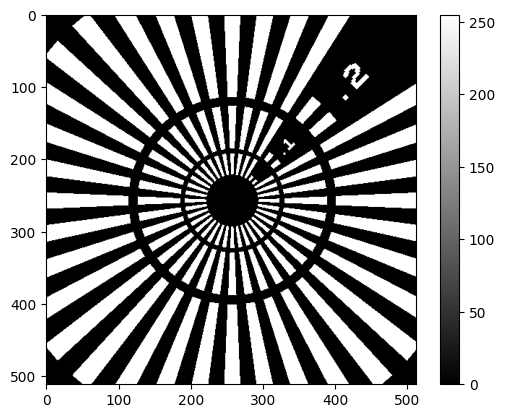

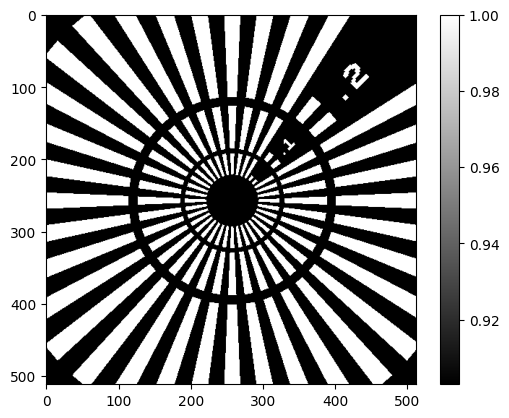

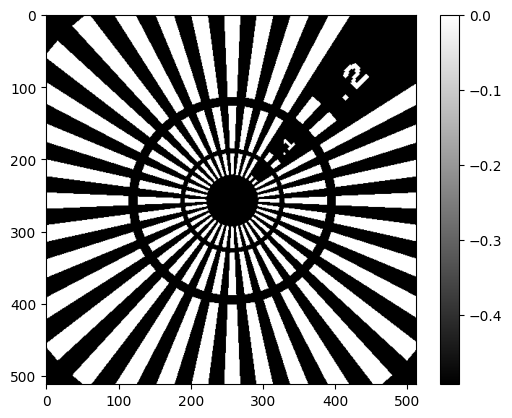

aperture [pix] :  195


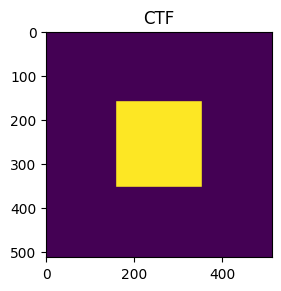

In [8]:
# スターチャート画像の読み込み
img = np.array(Image.open("./image/50nm_star_512pix.tif"))
plt.imshow(img, cmap="gray")
plt.colorbar()
plt.show()
imax, jmax = img.shape
object_img = (img) / np.max(img)
object_img = np.where(object_img==0 , np.exp(1.0j * 2.0 * np.pi / xlambda * refraction * thickness), 1.0)
obA = np.abs(object_img)
obP = np.angle(object_img)
plt.imshow(obA,cmap="gray")
plt.colorbar()
plt.show()
plt.imshow(obP,cmap="gray")
plt.colorbar()
plt.show()

# 開口サイズの計算
aperture = pixel_size * m * 2.0 * np.tan(NA)/xlambda     # [pixel]
print("aperture [pix] : ", int(aperture))
seq = np.linspace(-1.0*n/aperture, 1.0*n/aperture, int(n))


# 開口マスク作成
CTF = np.zeros((n,m))
CTF[n//2-int(aperture//2) : n//2+int(aperture//2),
    m//2-int(aperture//2) : m//2+int(aperture//2)] = 1.0
plt.subplot(1,2,1)
plt.title("CTF")
plt.imshow(CTF)
plt.show()



In [9]:
# Legendre波面作成用メッシュグリッド
[x, y] = np.meshgrid(np.linspace(-1.0*n/aperture, 1.0*n/aperture, int(n)), np.linspace(-1.0*m/aperture, 1.0*m/aperture, int(m)))

dfx = 1.0 / (pixel_size * m)
dfy = 1.0 / (pixel_size * n)
fx = np.arange(-m/2, m/2) * dfx
fy = np.arange(-n/2, n/2) * dfy
fx = tf.constant(fx, dtype=tf.float32)
fy = tf.constant(fy, dtype=tf.float32)
fx_mesh, fy_mesh = tf.meshgrid(fx, fy)
fz2 = 1.0 / xlambda ** 2 - fx_mesh ** 2 - fy_mesh ** 2
fz2 = tf.where(fz2 > 0.0, fz2, 0.0)
fz = tf.sqrt(fz2)

B = Legendre_basis_6(x, y)

# 焼きなまし法

In [10]:
N = 2

target = [random.uniform(0.0, coef_w)-coef_w/2 for i in range(N)]   # Legendre多項式の係数
coef = [0.0] * mode


# coef[3], coef[5], coef[6], coef[9], coef[10], coef[14], coef[15], coef[20],coef[21], coef[27] = target
coef[3], coef[5] = target



start_coef = coef
print(coef)

[0.0, 0.0, 0.0, 1.6668929044147016, 0.0, -0.5959515619591125, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [11]:
sa = SA(T, cool, target, limit, sigma, min_sigma, 0.995)

def main(total_step=500, num = 10):
    score_list = []

    all_step_count = 0
    _, img_total = pseudo_incoherent(coef, theta_x, theta_y, defocus=25e-6, crop_size=256)
    score = laplacian_score(img_total)
    for step in range(total_step):
        if step % 50 ==0:
          print(f'{step}step')
        _,before=sa.action()
        if num == 10:
          coef[3], coef[5], coef[6], coef[9], coef[10], coef[14], coef[15], coef[20],coef[21], coef[27] = target
        elif num == 2:
          coef[3], coef[5] = target
        # print('target',test.v_list)
        _, img_total = pseudo_incoherent(coef, theta_x, theta_y, defocus=25e-6, crop_size=256)
        score_next = laplacian_score(img_total)
        flag,blur = sa.step(score,score_next) #行動選択
        if flag:
            sa.target = before
            if num == 10:
              coef[3], coef[5], coef[6], coef[9], coef[10], coef[14], coef[15], coef[20],coef[21], coef[27] = target
            elif num == 2:
              coef[3], coef[5] = target
        else:
            score = score_next
            print('移動')
            print(f'coef : {coef}')

        score_list.append(score)
        sa.T_cool()
        print('blur',score)
    return score_list

In [12]:
score_list = main(num = N)

0step
移動
coef : [0.0, 0.0, 0.0, 1.6668929044147016, 0.0, -0.5959515619591125, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
blur 0.018762449539436427
blur 0.018762449539436427
blur 0.018762449539436427
blur 0.018762449539436427
blur 0.018762449539436427
移動
coef : [0.0, 0.0, 0.0, 1.6668929044147016, 0.0, -0.5959515619591125, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
blur 0.019005244374706073
blur 0.019005244374706073
blur 0.019005244374706073
blur 0.019005244374706073
blur 0.019005244374706073
blur 0.019005244374706073
blur 0.019005244374706073
blur 0.019005244374706073
blur 0.019005244374706073
blur 0.019005244374706073
blur 0.019005244374706073
blur 0.019005244374706073
blur 0.019005244374706073
blur 0.019005244374706073
blur 0.019005244374706073
blur 0.019005244374706073
blur 0.019005244374706073
blur 0.019005244374706073
blur 0.019005244374706073
blur 0